# Feature Selection

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:

df = pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [6]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [8]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [10]:
# drop month daya dnyear
df.drop(['day', 'month', 'year'], axis =1, inplace = True)

In [12]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [14]:
df['Classes'].value_counts()

Classes
fire             131
not fire         100
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [16]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0,1)

In [18]:
df['Classes'].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [20]:
df["FWI"].value_counts()

FWI
0.4    12
0.8    10
0.5     9
0.1     9
0.0     9
       ..
4.1     1
8.4     1
8.3     1
9.7     1
6.5     1
Name: count, Length: 125, dtype: int64

In [22]:
X = df.drop('FWI', axis = 1)
y = df['FWI']

In [24]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
237,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
238,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
239,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
240,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [26]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
237    6.5
238    0.0
239    0.2
240    0.7
241    0.5
Name: FWI, Length: 242, dtype: float64

In [28]:
## Train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [30]:
X_train.shape

(181, 11)

In [32]:
y_train.shape

(181,)

In [34]:
## Feature Selection
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.650346,-0.302105,-0.329711,0.703237,0.494261,0.377424,0.617606,0.466352,0.525551,0.249598
RH,-0.650346,1.000000,0.266525,0.234932,-0.634330,-0.413931,-0.246125,-0.693939,-0.364136,-0.435094,-0.364007
Ws,-0.302105,0.266525,1.000000,0.219681,-0.171843,0.000277,0.105115,0.005360,0.038701,-0.059470,-0.235477
Rain,-0.329711,0.234932,0.219681,1.000000,-0.546501,-0.286855,-0.300276,-0.346706,-0.297934,-0.386323,-0.065132
FFMC,0.703237,-0.634330,-0.171843,-0.546501,1.000000,0.621240,0.537884,0.751558,0.610780,0.780805,0.222702
DMC,0.494261,-0.413931,0.000277,-0.286855,0.621240,1.000000,0.876734,0.693404,0.983698,0.613507,0.196778
DC,0.377424,-0.246125,0.105115,-0.300276,0.537884,0.876734,1.000000,0.548992,0.946992,0.546427,-0.081403
ISI,0.617606,-0.693939,0.005360,-0.346706,0.751558,0.693404,0.548992,1.000000,0.659589,0.749722,0.266275
BUI,0.466352,-0.364136,0.038701,-0.297934,0.610780,0.983698,0.946992,0.659589,1.000000,0.609708,0.096607
Classes,0.525551,-0.435094,-0.059470,-0.386323,0.780805,0.613507,0.546427,0.749722,0.609708,1.000000,0.161852


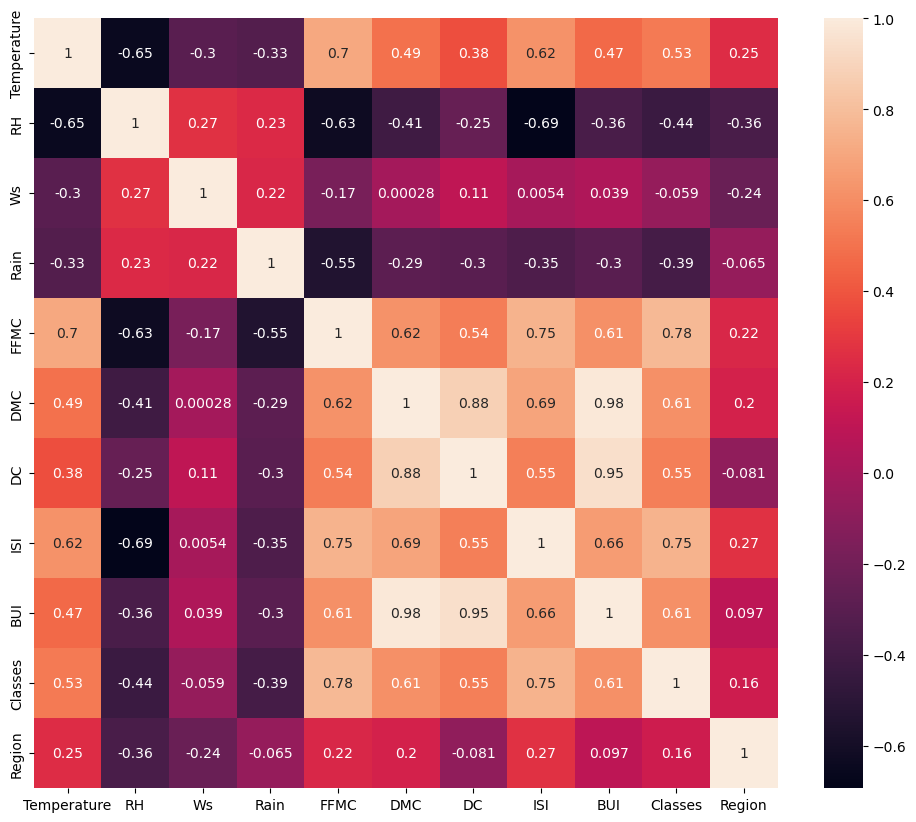

In [36]:
## check for multicollinarity
plt.figure(figsize= (12,10))
corr = X_train.corr()
sns.heatmap(corr, annot = True)
plt.show()

In [38]:
## finding highly corealted columns
def correlation(dataset, threshold):
    corr_columns = set()
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                corr_columns.add(corr_matrix.columns[i])
    return corr_columns

In [40]:
# threshold--Domain expertise
correlation(X_train, 0.95)

{'BUI'}

In [42]:
## Now as we see, the BUI is highly correalted to DMC, so we dropped BUI.

X_train.drop('BUI', axis = 1, inplace = True)
X_test.drop("BUI", axis = 1, inplace = True)

In [44]:
X_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,32.2,2.1,0,0
141,32,55,14,0.0,86.2,8.3,18.4,5.0,1,1
230,29,41,8,0.1,83.9,24.9,86.0,2.7,1,1
68,32,60,18,0.3,77.1,11.3,47.0,2.2,0,0
119,32,47,14,0.7,77.5,7.1,8.8,1.8,0,0


In [46]:
X_train.shape, y_train.shape

((181, 10), (181,))

# Feature scaling or Standarlization

In [49]:
from sklearn.preprocessing  import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
X_train_scaled

array([[-0.82836812,  0.75305576,  1.27406033, ..., -0.60658617,
        -1.07459849, -0.98356052],
       [-0.02800533, -0.52331623, -0.52192814, ...,  0.08124507,
         0.93058013,  1.01671425],
       [-0.82836812, -1.46380085, -2.67711431, ..., -0.46427625,
         0.93058013,  1.01671425],
       ...,
       [-1.89551851,  0.88741071,  0.55566494, ..., -1.05723422,
        -1.07459849, -0.98356052],
       [ 1.03914506, -0.45613875,  0.19646725, ...,  0.84023126,
         0.93058013,  1.01671425],
       [-0.56158052,  0.95458818,  1.99245572, ..., -0.84376935,
        -1.07459849, -0.98356052]])

In [53]:
X_test_scaled

array([[-2.94792925e-01,  8.12810312e-02, -1.62730447e-01,
        -3.85999528e-01,  6.56737443e-01, -2.44163592e-02,
         3.14386967e-01,  2.47273297e-01,  9.30580132e-01,
        -9.83560524e-01],
       [ 2.38782269e-01, -5.90493701e-01, -8.81125837e-01,
        -3.85999528e-01,  7.60996720e-01, -3.68055643e-01,
        -3.83115358e-01,  4.13301526e-01,  9.30580132e-01,
        -9.83560524e-01],
       [ 2.38782269e-01, -9.93558541e-01,  1.96467247e-01,
        -3.85999528e-01,  7.19293009e-01, -5.27887868e-01,
        -6.49129759e-01,  5.08174800e-01,  9.30580132e-01,
         1.01671425e+00],
       [ 7.72357464e-01, -6.57671175e-01,  5.55664942e-01,
        -1.48036604e-01,  2.04947242e-01,  4.95038372e-01,
         2.10317672e+00, -4.64276255e-01,  9.30580132e-01,
         1.01671425e+00],
       [-5.61580522e-01,  1.48458504e-01, -5.21928142e-01,
        -3.85999528e-01,  5.66379403e-01,  1.19432643e-01,
        -8.98711373e-02, -3.73465235e-02,  9.30580132e-01,
         1.

## Box Plots to understand Effect of Standard Scaler

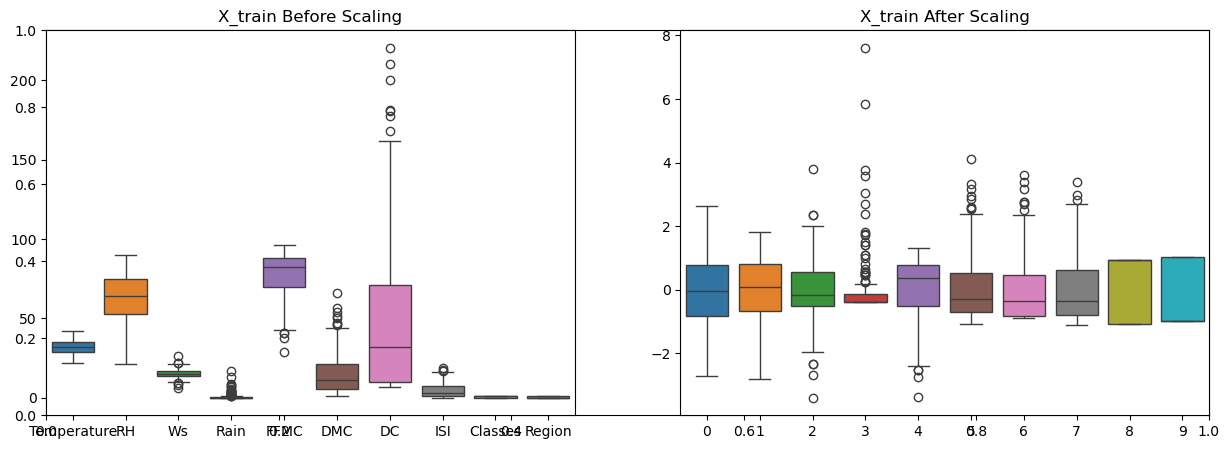

In [56]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title('X_train After Scaling')
plt.show()

# Linear Regression Model

In [59]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)


In [61]:
y_pred

array([ 8.26201905e+00,  7.46897026e+00,  7.03099157e+00,  8.31357188e+00,
        6.70043604e+00,  1.03332237e+01,  1.07669722e+01,  2.31496752e+00,
        1.66394305e+00,  3.17466532e+00,  1.19430854e-01,  1.07653616e+01,
        9.48211525e+00,  2.83605670e+01,  1.90227374e+01,  6.85136593e-01,
        5.06130277e+00, -1.21202019e-01,  6.82822337e+00,  6.32548130e+00,
        1.20607494e+00,  3.07314046e-01,  6.38276060e+00,  1.19813044e-01,
        2.06812465e+01,  1.38805192e+01,  5.91431394e+00,  1.00023004e+01,
        2.70638124e-02,  1.49236854e+01,  6.38684219e+00, -2.17734783e-01,
        1.03480094e+01,  1.50800027e+01,  1.21046115e+00,  3.33950183e+00,
        2.02083026e+00,  6.34550137e+00, -1.87691561e-02, -1.30082092e-01,
        7.31457852e+00,  1.42572703e+00,  8.37030577e+00, -3.14812604e-01,
        1.53395441e+01,  7.98947274e+00,  9.33974612e+00,  8.96118951e-01,
       -6.42606072e-02,  8.88491157e-01,  2.88889250e+01,  3.63990262e+00,
        1.23212191e+01,  

In [63]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)


Mean absolute error 0.9933273952968782
R2 Score 0.9798407754773322


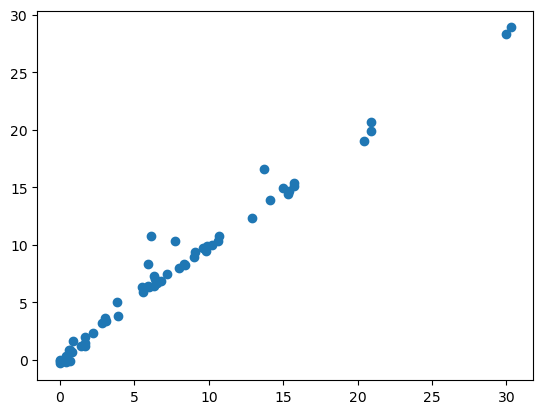

In [65]:
plt.scatter(y_test, y_pred)
plt.show()

## Lasso Regression

Mean absolute error 2.4816613158299985
R2 Score 0.9496355704152465


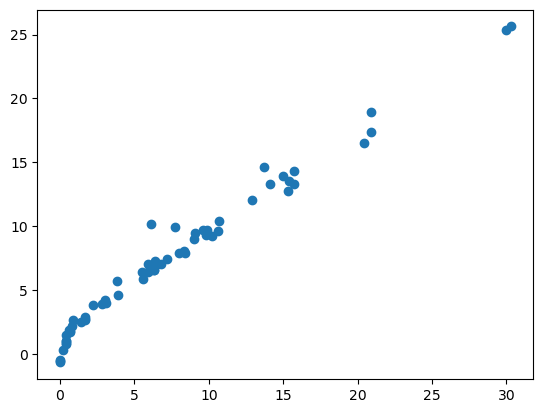

In [68]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

plt.scatter(y_test, y_pred)
plt.show()

In [72]:
## Cross Validation Lasso
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv = 5)

In [74]:
lassocv.fit(X_train_scaled, y_train)

LassoCV(cv=5)

In [76]:
lassocv.predict(X_test_scaled)

array([ 8.24129066,  7.39006088,  7.05100402,  8.05745207,  6.83825156,
       10.24536961, 10.62908754,  2.50353718,  1.99863688,  3.23226549,
        0.39752048, 10.91310388,  9.52546865, 28.05938732, 18.76954492,
        0.94930153,  5.39183596, -0.7289541 ,  6.95030238,  6.20453699,
        1.73457522,  0.27455726,  6.29810704, -0.05569369, 20.57552897,
       13.86563322,  5.85631052,  9.91678082, -0.69540056, 14.89863553,
        6.55797674, -0.13281433, 10.29627153, 14.90895717,  1.44800576,
        3.31673877,  2.0579279 ,  6.15640908,  0.07806175, -0.31653409,
        7.0093986 ,  1.7139125 ,  8.25871773, -0.89485878, 15.25845924,
        8.0124931 ,  9.46013451,  0.88276361,  0.38008469,  0.90494842,
       28.50062391,  3.44555568, 12.44536343, 19.68704149, 14.27455337,
       16.47023289,  9.70428863,  9.02962192,  4.03868872, 14.48722172,
        9.99201577])

In [78]:
lassocv.alpha_
# this is the alpha value that got selected

0.05636933697829682

In [80]:
# these are the alpha values that the model tried to find the best alpha value
lassocv.alphas_


array([6.94947533, 6.48110395, 6.04429924, 5.6369337 , 5.25702323,
       4.90271746, 4.57229071, 4.26413362, 3.97674529, 3.70872596,
       3.45877025, 3.22566071, 3.00826197, 2.80551518, 2.61643285,
       2.44009403, 2.27563986, 2.12226935, 1.9792355 , 1.84584165,
       1.7214381 , 1.60541894, 1.49721907, 1.39631152, 1.3022048 ,
       1.21444055, 1.13259132, 1.05625846, 0.98507017, 0.91867974,
       0.8567638 , 0.79902079, 0.74516946, 0.69494753, 0.6481104 ,
       0.60442992, 0.56369337, 0.52570232, 0.49027175, 0.45722907,
       0.42641336, 0.39767453, 0.3708726 , 0.34587702, 0.32256607,
       0.3008262 , 0.28055152, 0.26164329, 0.2440094 , 0.22756399,
       0.21222694, 0.19792355, 0.18458417, 0.17214381, 0.16054189,
       0.14972191, 0.13963115, 0.13022048, 0.12144406, 0.11325913,
       0.10562585, 0.09850702, 0.09186797, 0.08567638, 0.07990208,
       0.07451695, 0.06949475, 0.06481104, 0.06044299, 0.05636934,
       0.05257023, 0.04902717, 0.04572291, 0.04264134, 0.03976

In [82]:
lassocv.mse_path_

array([[54.83966454, 59.07855795, 38.72729712, 78.24916791, 53.00661707],
       [48.33127443, 52.98238939, 33.40705056, 76.17370919, 47.37592787],
       [42.489492  , 46.9476325 , 28.61641869, 69.11179183, 42.46600092],
       [37.38816074, 41.6222327 , 24.54198449, 62.88571919, 38.18380814],
       [32.93231013, 36.95463498, 21.08421335, 57.39228141, 33.53847098],
       [29.03908563, 32.86149181, 18.15701813, 52.54133041, 29.14966015],
       [25.63631212, 29.27011099, 15.68586523, 48.25410422, 25.34331445],
       [22.66140204, 26.11749884, 13.60632992, 43.16468118, 22.0425561 ],
       [20.05957707, 23.34834079, 11.86266757, 37.9874641 , 19.18168383],
       [17.78321296, 20.91452315, 10.40680285, 33.46741145, 16.70233718],
       [15.79082322, 18.77407566,  9.19714128, 29.52048402, 14.5542223 ],
       [14.0461701 , 16.89025254,  8.19780164, 26.07233474, 12.69363691],
       [12.51796119, 15.23137028,  7.37783328, 23.06047803, 11.08260866],
       [11.17864417, 13.76938633,  6.7

In [84]:
y_pred = lassocv.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 1.079338129255969
R2 Score 0.9780952183675108


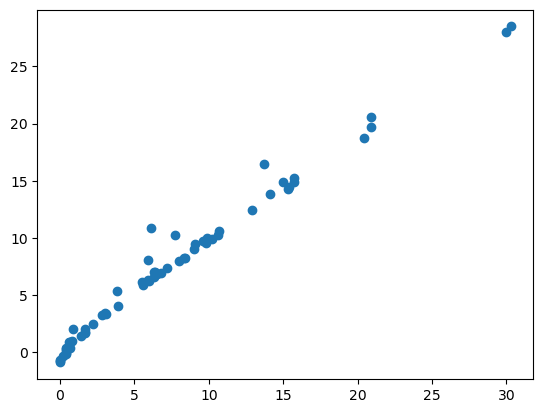

In [86]:
plt.scatter(y_test, y_pred)
plt.show()

## Ridge Regression

Mean absolute error 1.064760355827925
R2 Score 0.9783910690698754


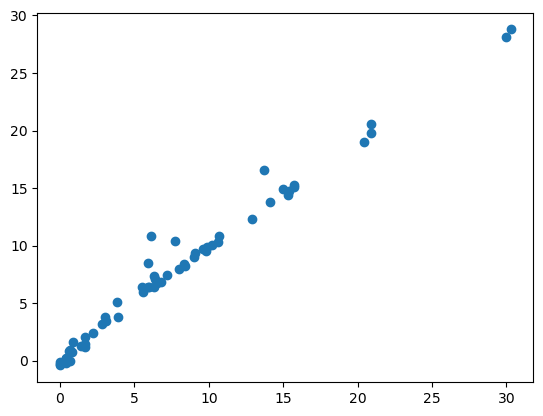

In [121]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

plt.scatter(y_test, y_pred)
plt.show()

In [105]:
## Cross Validation Ridge


Mean absolute error 1.7692446854361492
R2 Score 0.9640938113474818


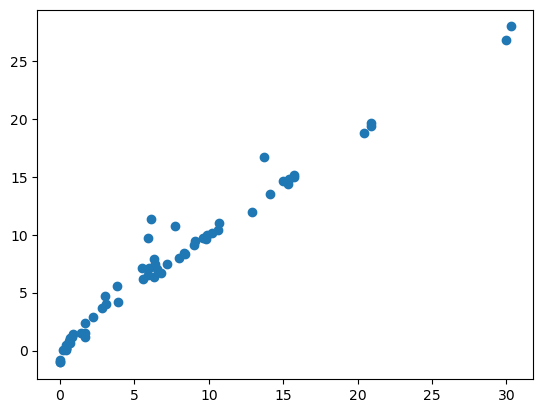

In [107]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv  = 5)
ridgecv.fit(X_train_scaled, y_train)

y_pred = ridgecv.predict(X_test_scaled)

mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

plt.scatter(y_test, y_pred)
plt.show()

In [109]:
ridgecv.alpha_

10.0

In [111]:
ridgecv.coef_

array([ 0.07450553, -0.44004253,  0.14412781,  0.03583628, -0.57158707,
        2.52650694,  1.1902222 ,  3.9456369 ,  0.64168523, -0.04016886])

In [113]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

## ElaSTICNET 

Mean absolute error 6.25559016721004
R2 Score 0.8730450329874468


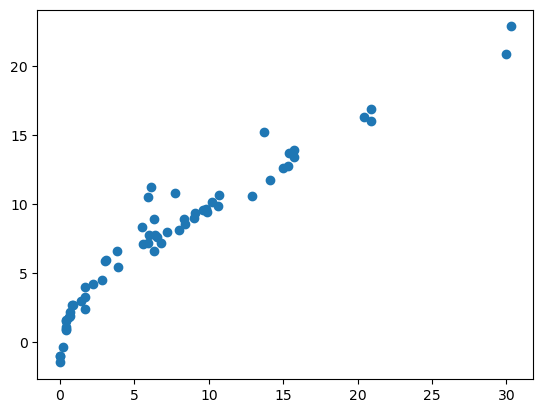

In [127]:
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled, y_train)
y_pred = elasticnet.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

plt.scatter(y_test, y_pred)
plt.show()

In [129]:
## Elasticnetcv Cross Validation

Mean absolute error 1.3274826767850831
R2 Score 0.973059213449696


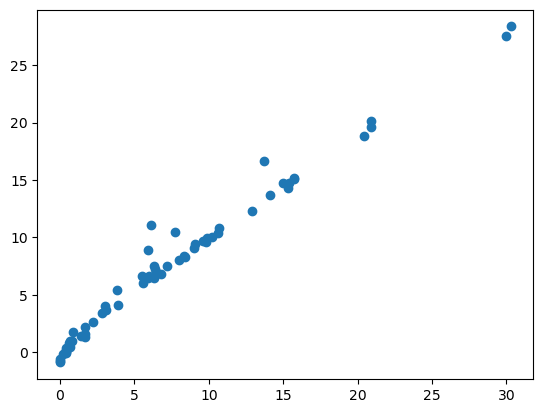

In [132]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_scaled, y_train)

y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)


plt.scatter(y_test, y_pred)
plt.show()

In [138]:
## Pickel tge machine learning models, preprocessing model standard scaler

In [140]:
StandardScaler()

StandardScaler()

In [144]:
Ridge()

Ridge()

In [148]:
import pickle
pickle.dump(scaler, open('scaler.pkl','wb'))
pickle.dump(ridge, open('ridge.pkl','wb'))